In [ ]:
# Step 1 - Importing Relevant Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import preprocessing        # for minmax_scale (Topic 9)
from sklearn.model_selection import train_test_split  # for splitting data
from sklearn.neighbors import KNeighborsClassifier    # kNN model
from sklearn import metrics              # for accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Step 2 - Load Dataset
# Ensure that penguins_lter.csv file have been imported into Google Collab
df = pd.read_csv("penguins_lter.csv")

print("Raw data (first 5 rows):")
print(df.head())
print("\nInfo:")
print(df.info())
print("\nMissing values per column:")
print(df.isna().sum())

Raw data (first 5 rows):
  studyName  Sample Number                              Species  Region  \
0   PAL0708              1  Adelie Penguin (Pygoscelis adeliae)  Anvers   
1   PAL0708              2  Adelie Penguin (Pygoscelis adeliae)  Anvers   
2   PAL0708              3  Adelie Penguin (Pygoscelis adeliae)  Anvers   
3   PAL0708              4  Adelie Penguin (Pygoscelis adeliae)  Anvers   
4   PAL0708              5  Adelie Penguin (Pygoscelis adeliae)  Anvers   

      Island               Stage Individual ID Clutch Completion  Date Egg  \
0  Torgersen  Adult, 1 Egg Stage          N1A1               Yes  11/11/07   
1  Torgersen  Adult, 1 Egg Stage          N1A2               Yes  11/11/07   
2  Torgersen  Adult, 1 Egg Stage          N2A1               Yes  11/16/07   
3  Torgersen  Adult, 1 Egg Stage          N2A2               Yes  11/16/07   
4  Torgersen  Adult, 1 Egg Stage          N3A1               Yes  11/16/07   

   Culmen Length (mm)  Culmen Depth (mm)  Flipper Lengt

In [ ]:
#Step 3 - Selecting Relevant Variables (X and Y)
numeric_features = [
    "Culmen Length (mm)",
    "Culmen Depth (mm)",
    "Flipper Length (mm)",
    "Body Mass (g)"
]


target_col = "Sex"

df_model = df[numeric_features + [target_col]].copy()
print("\nSubset for modeling (first 5 rows):")
print(df_model.head())



Subset for modeling (first 5 rows):
   Culmen Length (mm)  Culmen Depth (mm)  Flipper Length (mm)  Body Mass (g)  \
0                39.1               18.7                181.0         3750.0   
1                39.5               17.4                186.0         3800.0   
2                40.3               18.0                195.0         3250.0   
3                 NaN                NaN                  NaN            NaN   
4                36.7               19.3                193.0         3450.0   

      Sex  
0    MALE  
1  FEMALE  
2  FEMALE  
3     NaN  
4  FEMALE  


Issue identified: NA values (Require Data Cleaning)


In [ ]:
# Step 4 - Data Cleaning

#Drop rows where Sex is missing (no label -> can't train)
before = df_model.shape[0]
df_model = df_model.dropna(subset=[target_col])
after = df_model.shape[0]
print(f"\nDropped {before - after} rows with missing Sex.")

#Drop rows where any numeric feature is missing
before = df_model.shape[0]
df_model = df_model.dropna(subset=numeric_features)
after = df_model.shape[0]
print(f"Dropped {before - after} rows with missing numeric values.")

#Clean Sex values (strip spaces, uppercase)
df_model[target_col] = df_model[target_col].str.strip().str.upper()
print("\nUnique Sex values after cleaning:", df_model[target_col].unique())

#Keep only FEMALE and MALE (drop weird entries if any)
valid_sex = ["FEMALE", "MALE"]
before = df_model.shape[0]
df_model = df_model[df_model[target_col].isin(valid_sex)]
after = df_model.shape[0]
print(f"Dropped {before - after} rows with non-standard Sex labels.")
print("Final dataset shape:", df_model.shape)

#Display final dataframe
display(df_model)



Dropped 10 rows with missing Sex.
Dropped 0 rows with missing numeric values.

Unique Sex values after cleaning: ['MALE' 'FEMALE' '.']
Dropped 1 rows with non-standard Sex labels.
Final dataset shape: (333, 5)


,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
4,36.7,19.3,193.0,3450.0,FEMALE
5,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,FEMALE
340,46.8,14.3,215.0,4850.0,FEMALE
341,50.4,15.7,222.0,5750.0,MALE
342,45.2,14.8,212.0,5200.0,FEMALE


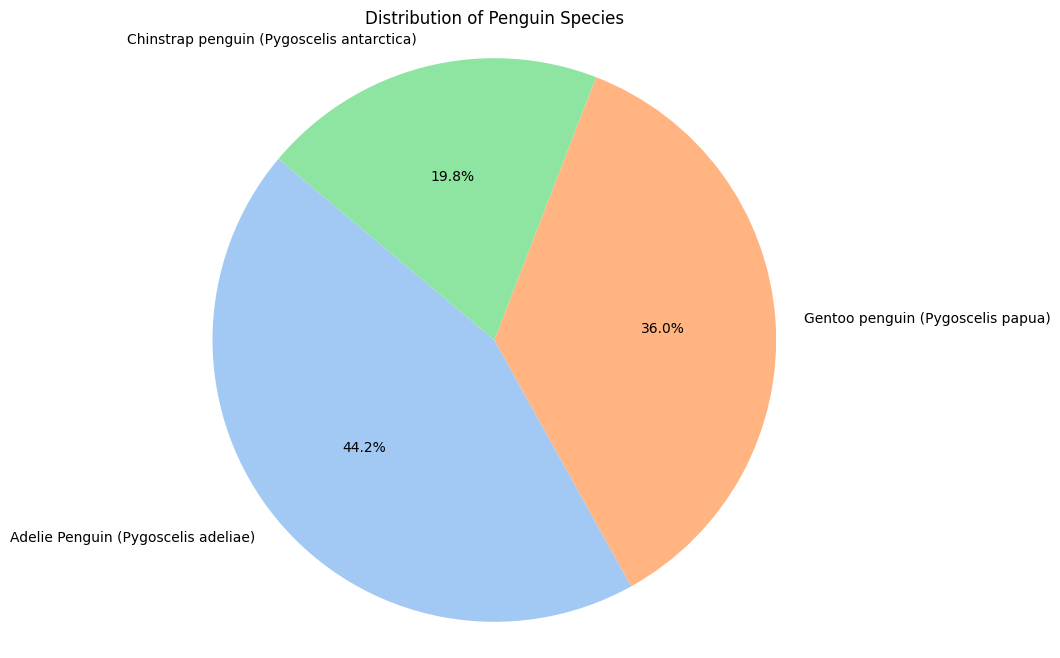

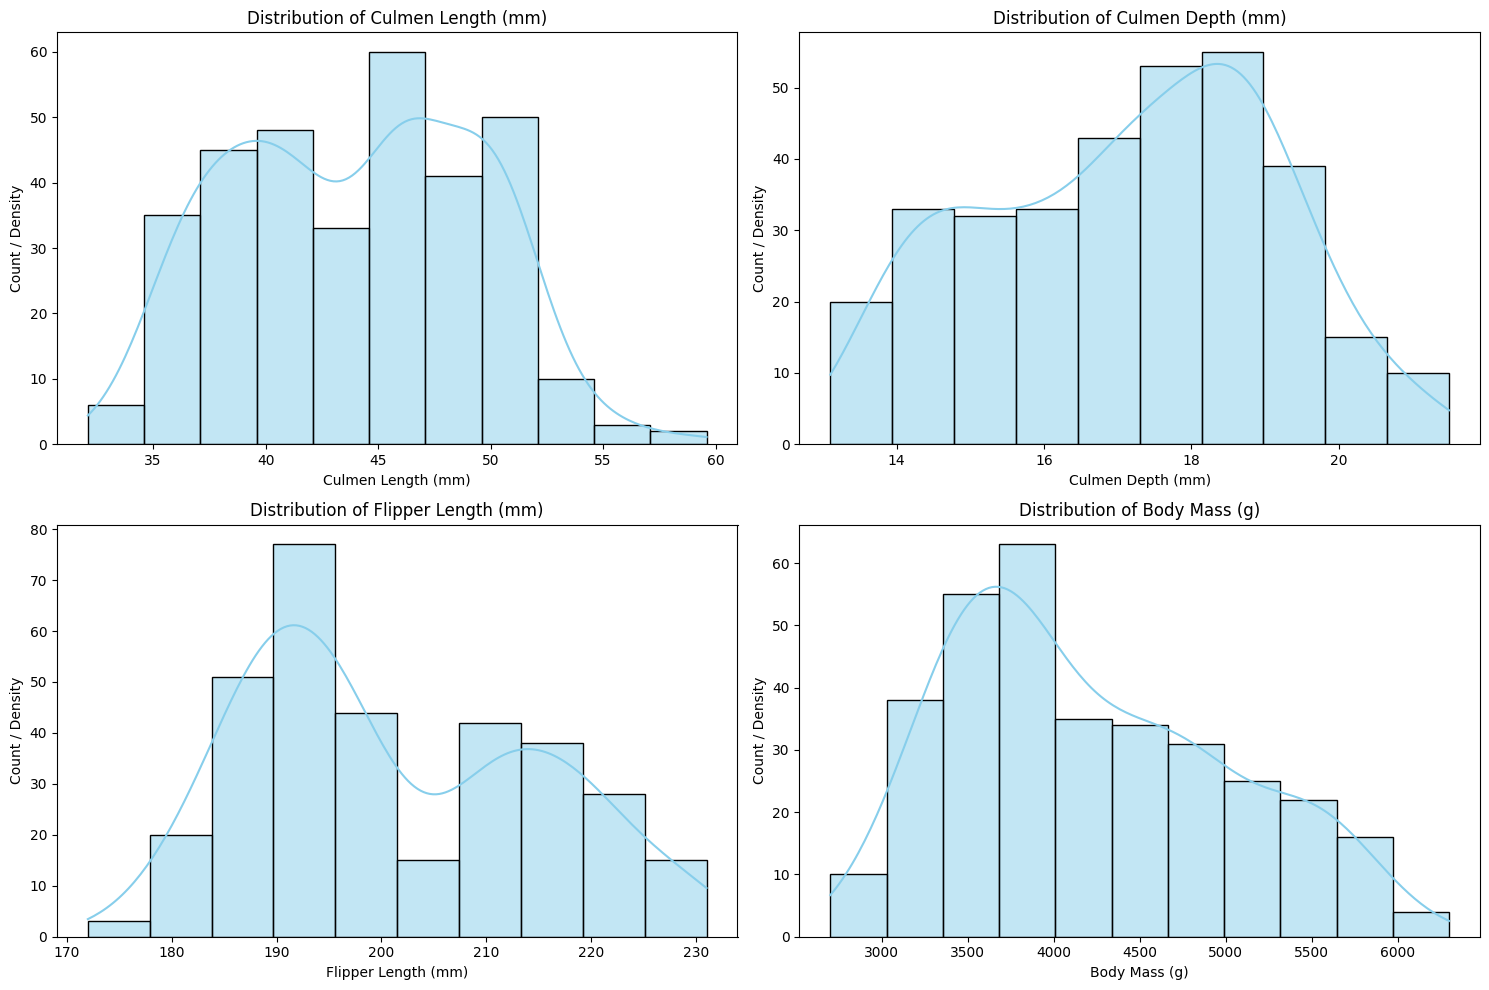

In [ ]:
# Step 4.1 Data Visualisation of Cleaned Data
species_counts = df['Species'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(species_counts, labels=species_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Penguin Species')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Distribution graphs for Culmen Length, Depth, Flipper Length, and Body Mass
plt.figure(figsize=(15, 10))

for i, feature in enumerate(numeric_features):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.histplot(
        data=df_model,
        x=feature,
        kde=True, # Overlay a Kernel Density Estimate
        color='skyblue' # A different color for these general distributions
    )
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count / Density')
plt.tight_layout()
plt.show()

In [ ]:
# Step 5 - Standardising the columns into numerical data
# Map Sex to numbers: FEMALE -> 0, MALE -> 1
sex_map = {"FEMALE": 0, "MALE": 1}
y = df_model[target_col].map(sex_map)

# Features: numeric columns
X_raw = df_model[numeric_features]

print("\nExample of X_raw (first 5 rows):")
print(X_raw.head())
print("\nExample of y (first 10 values):")
print(y.head())


Example of X_raw (first 5 rows):
   Culmen Length (mm)  Culmen Depth (mm)  Flipper Length (mm)  Body Mass (g)
0                39.1               18.7                181.0         3750.0
1                39.5               17.4                186.0         3800.0
2                40.3               18.0                195.0         3250.0
4                36.7               19.3                193.0         3450.0
5                39.3               20.6                190.0         3650.0

Example of y (first 10 values):
0    1
1    0
2    0
4    0
5    1
Name: Sex, dtype: int64


In [ ]:
# Step 6 MinMax Scaling
X_scaled_array = preprocessing.minmax_scale(X_raw)  # returns numpy array
X_scaled = pd.DataFrame(X_scaled_array, columns=numeric_features)

print("\nScaled features (first 5 rows):")
print(X_scaled.head())



Scaled features (first 5 rows):
   Culmen Length (mm)  Culmen Depth (mm)  Flipper Length (mm)  Body Mass (g)
0            0.254545           0.666667             0.152542       0.291667
1            0.269091           0.511905             0.237288       0.305556
2            0.298182           0.583333             0.389831       0.152778
3            0.167273           0.738095             0.355932       0.208333
4            0.261818           0.892857             0.305085       0.263889


In [ ]:
# Step 7 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,       # 80% train, 20% test
    random_state=1
)

print("\nTrain set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])



Train set size: 266
Test set size: 67


In [ ]:
# Step 8 Building the kNN Model
# kNN classifier with k=3
k = 3
model = KNeighborsClassifier(n_neighbors=k)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = metrics.accuracy_score(y_test, y_pred)

print("Accuracy on test set:", accuracy)

Accuracy on test set: 0.8955223880597015


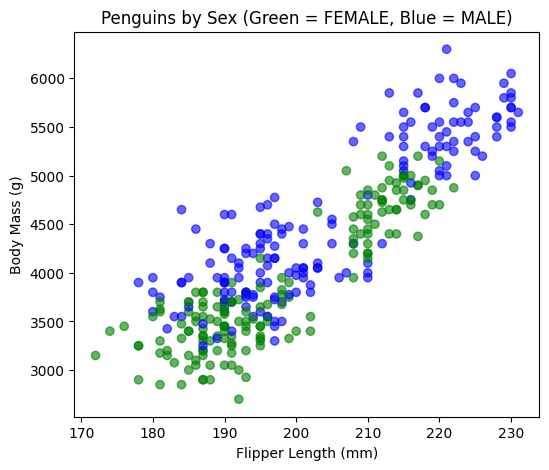

In [ ]:
# Step 9 Model Visualisation
plt.figure(figsize=(6, 5))
colors = df_model[target_col].map({"FEMALE": "green", "MALE": "blue"})

plt.scatter(
    df_model["Flipper Length (mm)"],
    df_model["Body Mass (g)"],
    c=colors,
    alpha=0.6
)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Penguins by Sex (Green = FEMALE, Blue = MALE)")
plt.show()
